In [6]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  

proxy = 'http://10.20.38.38:7890'
os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy
import sys
sys.path.append('/home/ldy/Closed_loop_optimizing/model')
import torch
from PIL import Image
from torchvision import transforms
import torchvision.models as models
import torch.nn as nn
from einops.layers.torch import Rearrange
import math
import importlib
# import util
# importlib.reload(util)
import json
import open_clip
import torch.nn.functional as F
from torch.utils.data import DataLoader
import random
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
import numpy as np

# 指定根目录
# directory = '/home/ldy/Closed_loop_optimizing/server/outputs/gaoyiou_female_1/clip'
# directory = '/home/ldy/Closed_loop_optimizing/server/outputs/gaoyiou_female_2/clip'
# directory = '/home/ldy/Closed_loop_optimizing/server/outputs/luweibin_male_1/clip'
# directory = '/home/ldy/Closed_loop_optimizing/server/outputs/luweibin_male_2/clip'
directory = '/home/ldy/Closed_loop_optimizing/server/outputs/mingjie_female_1/clip'
directory = '/home/ldy/Closed_loop_optimizing/server/outputs/mingjie_female_2/clip'
# directory = '/home/ldy/Closed_loop_optimizing/server/outputs/shenyuyang_male_1/clip'
# directory = '/home/ldy/Closed_loop_optimizing/server/outputs/shenyuyang_male_2/clip'
directory = '/home/ldy/Closed_loop_optimizing/server/outputs/suyu_male_1/clip'
directory = '/home/ldy/Closed_loop_optimizing/server/outputs/suyu_male_2/clip'
# directory = '/home/ldy/Closed_loop_optimizing/server/outputs/yichen_male_1/clip'
# directory = '/home/ldy/Closed_loop_optimizing/server/outputs/yichen_male_2/clip'
directory = '/home/ldy/Closed_loop_optimizing/server/outputs/yiming_male_1/clip'
directory = '/home/ldy/Closed_loop_optimizing/server/outputs/yiming_male_2/clip'
directory = '/home/ldy/Closed_loop_optimizing/server/outputs/yuanjiamu_female_1/clip'
directory = '/home/ldy/Closed_loop_optimizing/server/outputs/yuanjiamu_female_2/clip'
directory = '/home/ldy/Closed_loop_optimizing/server/outputs/zhaoquanbo_male_1/clip'
directory = '/home/ldy/Closed_loop_optimizing/server/outputs/zhaoquanbo_male_2/clip'
directory = '/home/ldy/Closed_loop_optimizing/server/outputs/zhouyijun_female_1/clip'
directory = '/home/ldy/Closed_loop_optimizing/server/outputs/zhouyijun_female_2/clip'




# 收集所有JSON文件中的列表内容
ratings = np.load(os.path.join(directory, "all_viewed_image_ratings.npy"), allow_pickle=True)

# 打印结果或进行其他处理
print(f"总共收集了 {len(ratings)} 个元素")

总共收集了 64 个元素


In [52]:
# 收集所有JSON文件中的列表内容
rewards = np.load(os.path.join(directory, "all_viewed_image_rewards.npy"), allow_pickle=True)

# 打印结果或进行其他处理
print(f"总共收集了 {len(rewards)} 个元素")

总共收集了 64 个元素


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def plot_correlation_scatter_with_ci(x, y, xlabel="Participant to RTNet", ylabel="Participant to group", save_path=""):
    """
    绘制带置信区间的相关散点图
    
    参数:
    x, y -- 两个numpy数组
    xlabel, ylabel -- 坐标轴标签
    """
    
    # 计算Pearson相关系数和p值
    r, p = stats.pearsonr(x, y)
    
    # 创建图形
    plt.figure(figsize=(6, 5.5), dpi=300)
    
    # 设置颜色
    point_color = '#1f77b4'  # 散点颜色
    line_color = '#1f77b4'   # 回归线颜色 (与散点相同)
    ci_color = '#8ab4d6'     # 更浅的蓝色用于置信区间
    
    # 绘制散点图 (增加透明度)
    plt.scatter(x, y, color=point_color, s=150, alpha=0.6, edgecolors='none')
    
    # 设置坐标轴标签
    plt.xlabel(xlabel, fontsize=22, fontfamily='sans-serif', labelpad=10)
    plt.ylabel(ylabel, fontsize=22, fontfamily='sans-serif', labelpad=10)
    
    # 计算回归线和置信区间
    slope, intercept = np.polyfit(x, y, 1)
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = slope * x_fit + intercept
    
    # 计算预测值的标准误差和置信区间
    y_err = y - (slope * x + intercept)
    x_mean = np.mean(x)
    n = len(x)
    stdev = np.sqrt(np.sum(y_err**2) / (n - 2))
    
    confidence = 0.95  # 95%置信区间
    t_val = stats.t.ppf((1 + confidence) / 2, n - 2)
    
    margin_of_error = t_val * stdev * np.sqrt(1/n + (x_fit - x_mean)**2 / np.sum((x - x_mean)**2))
    lower_bound = y_fit - margin_of_error
    upper_bound = y_fit + margin_of_error
    
    # 绘制置信区间 (使用更浅的蓝色)
    plt.fill_between(x_fit, lower_bound, upper_bound, color=ci_color, alpha=0.2)
    
    # 绘制回归线 (使用与散点相同的颜色)
    plt.plot(x_fit, y_fit, color=line_color, linewidth=3, alpha=0.8)
    
    # 添加统计信息
    stats_text = f"R = {r:.3f}\nP < 0.001" if p < 0.001 else f"R = {r:.3f}\nP = {p:.3f}"
    plt.text(0.98, 0.02, stats_text, transform=plt.gca().transAxes,
             fontsize=25, fontfamily='sans-serif',
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=4))
    
    # 调整坐标轴样式
    plt.tick_params(axis='both', which='major', labelsize=22)
    plt.grid(False)
    
    # 移除顶部和右侧边框
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)
    
    # 设置紧凑布局
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    
    return r, p

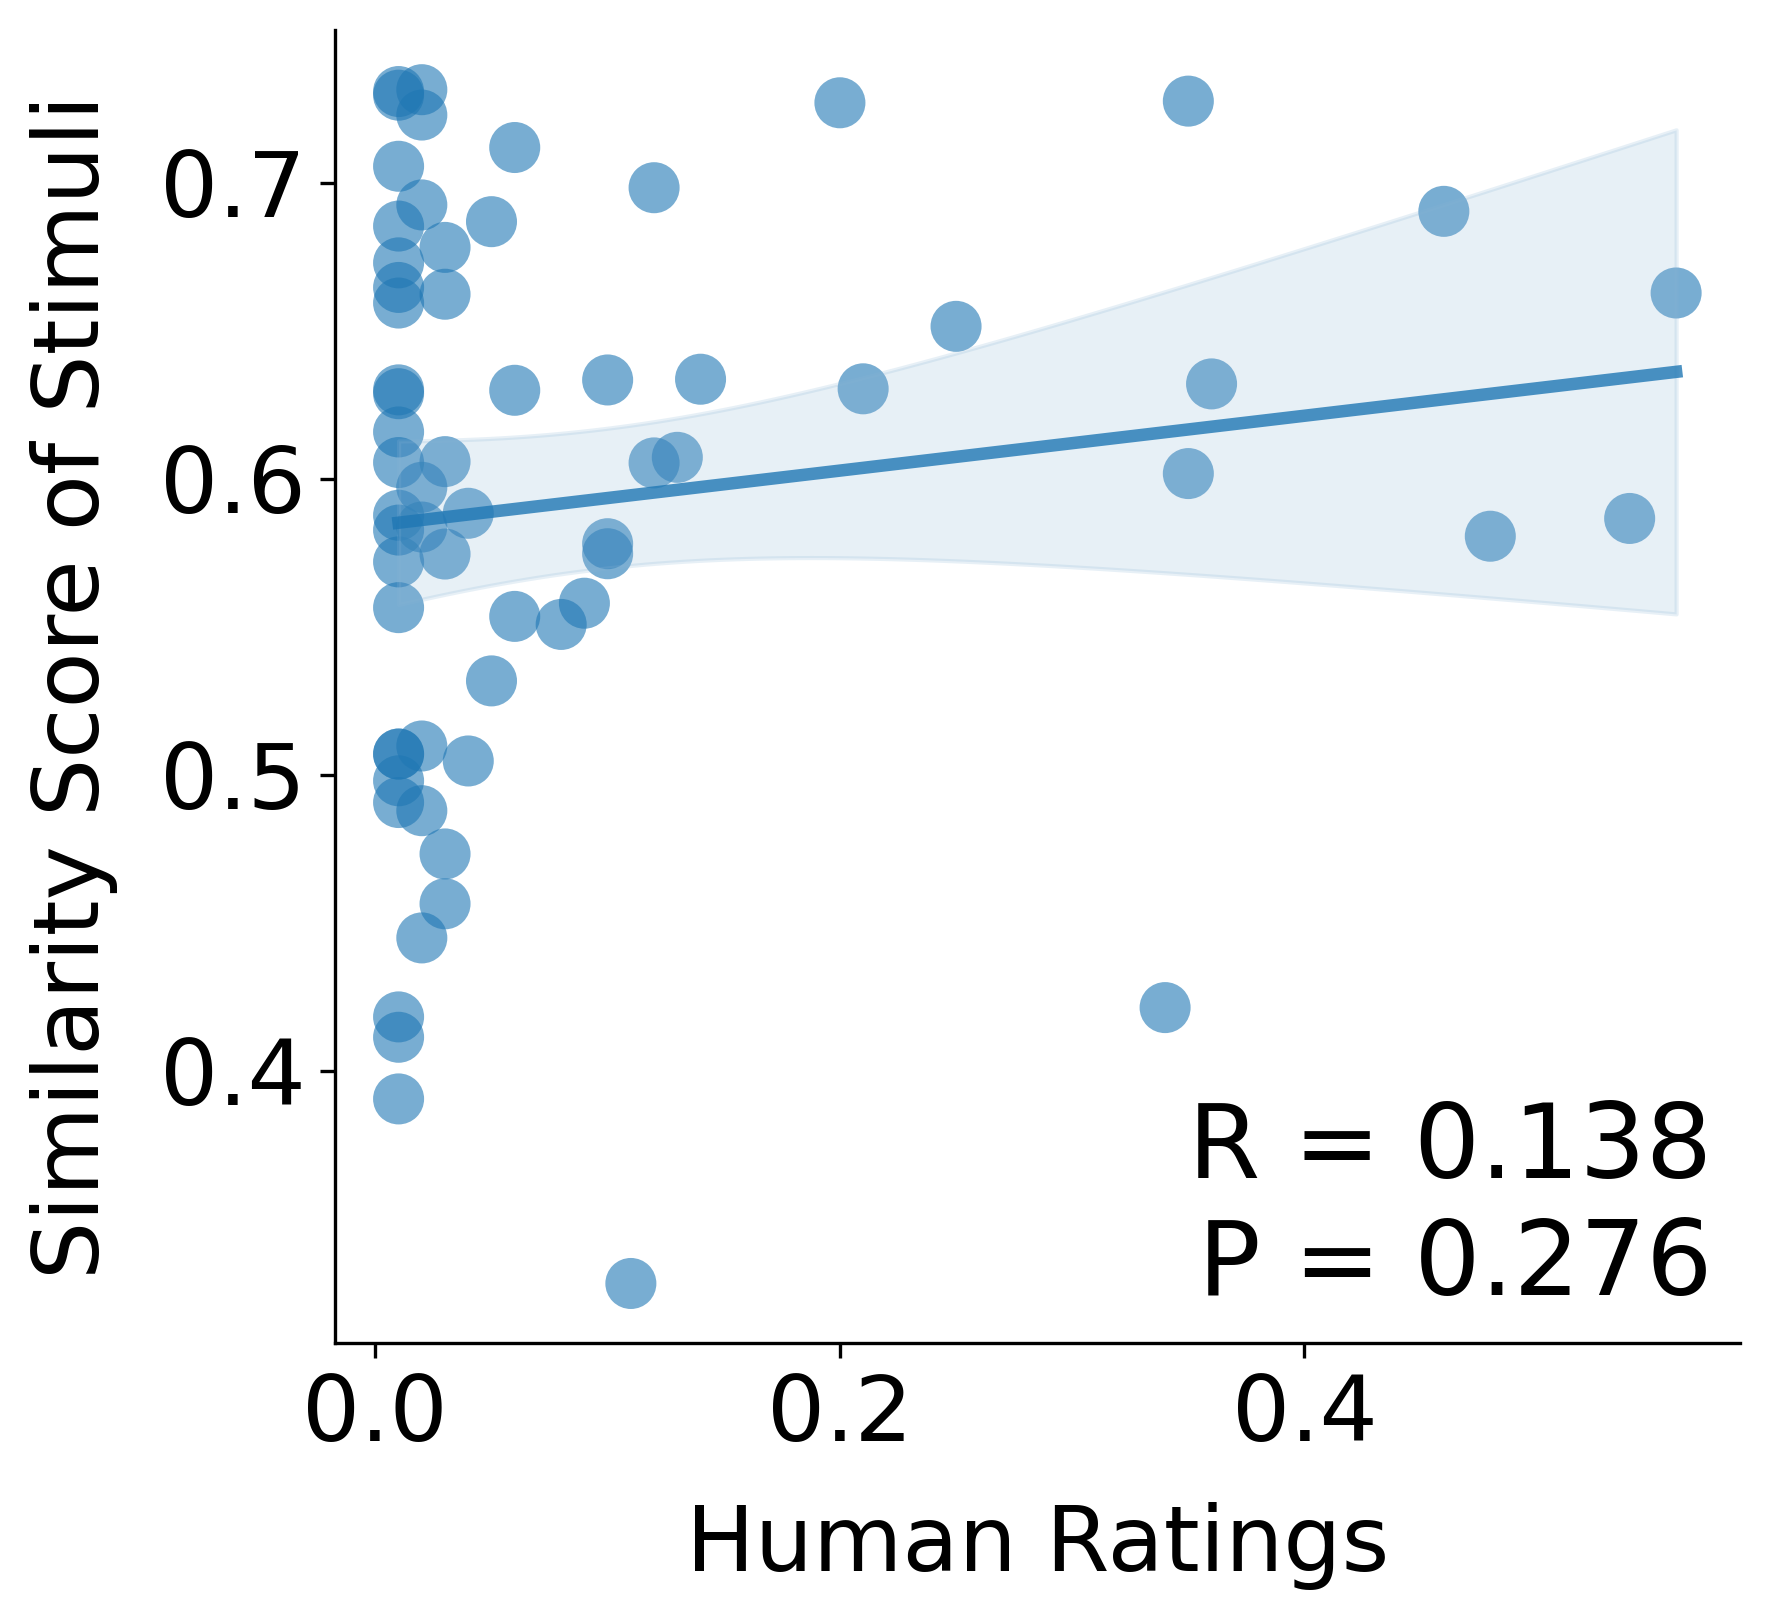

In [54]:
import numpy as np

# # 示例数据
# x = np.random.normal(0, 1, 100)
# y = x * 0.685 + np.random.normal(0, 0.5, 100)
ratings = np.array(ratings, dtype=np.float64)
rewards = np.array(rewards, dtype=np.float64)
# 调用函数
r, p = plot_correlation_scatter_with_ci(ratings, rewards, xlabel="Human Ratings", ylabel="Similarity Score of Stimuli", save_path="/home/ldy/Closed_loop_optimizing/Heuristic_generation/plots/rating_rewards_scatter_clip.png")